# ECG CLASSIFICATION

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Fixed typos in both class names
import warnings
warnings.filterwarnings('ignore')
print('lib imported')

lib imported


# Read the dataset and display few samples

In [3]:
df=pd.read_csv('ecg.csv', header=None)
print(df.shape)
print(df.info())
df.head()

(4998, 141)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Columns: 141 entries, 0 to 140
dtypes: float64(141)
memory usage: 5.4 MB
None


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


# split into input and target

In [4]:
X=df.iloc[:,:-1]
Y=df.iloc[:,-1:]

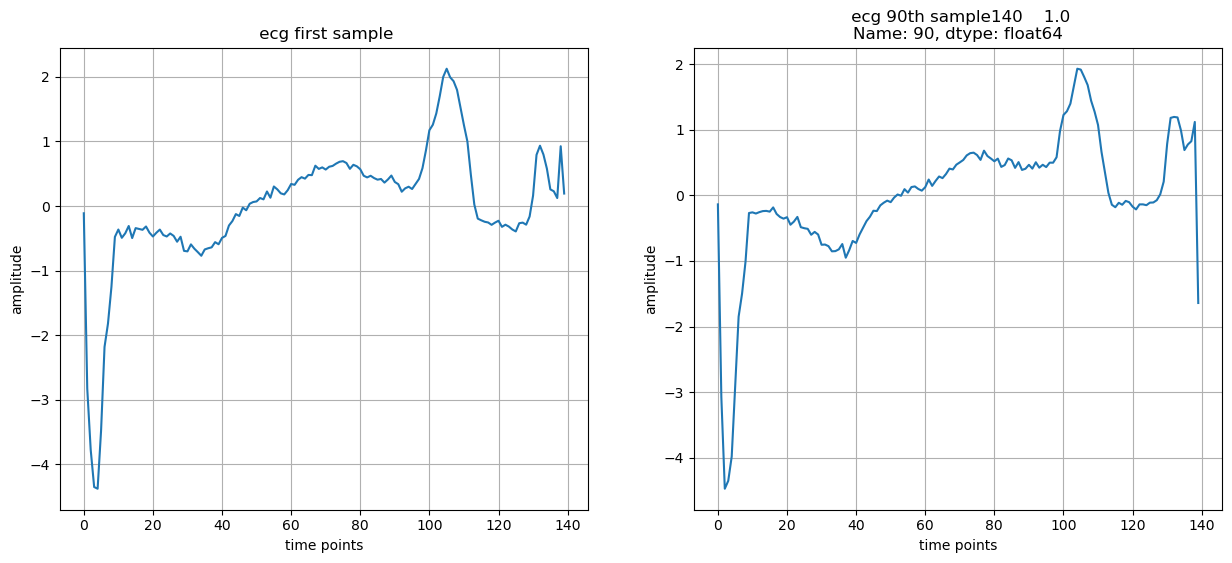

In [11]:
# display sample ECG
plt.figure(figsize=(15,6))

# first sample
plt.subplot(1,2,1)
plt.plot(X.iloc[0,:])
plt.title(' ecg first sample')
plt.xlabel('time points')
plt.ylabel('amplitude')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(X.iloc[90,:])
plt.title(' ecg 90th sample'+str(Y.iloc[90,:]))
plt.xlabel('time points')
plt.ylabel('amplitude')
plt.grid(True)

plt.show()

count

In [12]:
# count
df.iloc[:, -1].value_counts()

140
1.0    2919
0.0    2079
Name: count, dtype: int64

In [14]:
df.isnull().sum()
print('no missing values')

no missing values


In [15]:
# split the data into twiing an testing
Xtrain, Xtest, Ytrain, Ytest=train_test_split(X,Y, test_size=0.2)
print(Xtrain.shape, Ytrain.shape)
print(Xtest.shape, Ytest.shape)

(3998, 140) (3998, 1)
(1000, 140) (1000, 1)


In [16]:
# build the KNN model
KNN=KNeighborsClassifier(n_neighbors=5, p=2)
KNN.fit(Xtrain, Ytrain)

KNeighborsClassifier()

In [19]:
# testing
Ypredict=KNN.predict(Xtest)
cm=confusion_matrix(Ytest, Ypredict)
cm

array([[389,  12],
       [  4, 595]])

In [18]:
Y.dtypes

140    float64
dtype: object

In [20]:
accuracy_score(Ytest, Ypredict)

0.984

In [ ]:
#feature importance
feature_importance